In [3]:
import os
os.chdir(r'C:\Users\user\OneDrive\Documents\covid_analysis')
print("Working directory:", os.getcwd())

Working directory: C:\Users\user\OneDrive\Documents\covid_analysis


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 150
print("✅ All imports done")

✅ All imports done


In [5]:
df = pd.read_csv('data/covid_cleaned.csv')
df['date'] = pd.to_datetime(df['date'])
print("Shape:", df.shape)
df.head()

Shape: (395311, 20)


,iso_code,continent,location,date,total_cases,new_cases,total_deaths,new_deaths,total_vaccinations,people_vaccinated,people_fully_vaccinated,population,gdp_per_capita,life_expectancy,total_cases_per_million,total_deaths_per_million,new_cases_smoothed,new_deaths_smoothed,hospital_beds_per_thousand,human_development_index
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,0.0,0.0,0.0,0.0,55624.0,41128772,1803.99,64.83,0.0,0.0,0.0,0.0,0.5,0.51
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,0.0,0.0,0.0,0.0,55624.0,41128772,1803.99,64.83,0.0,0.0,0.0,0.0,0.5,0.51
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,0.0,0.0,0.0,0.0,55624.0,41128772,1803.99,64.83,0.0,0.0,0.0,0.0,0.5,0.51
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,0.0,0.0,0.0,0.0,55624.0,41128772,1803.99,64.83,0.0,0.0,0.0,0.0,0.5,0.51
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,0.0,0.0,0.0,0.0,55624.0,41128772,1803.99,64.83,0.0,0.0,0.0,0.0,0.5,0.51


In [6]:
COUNTRY = 'India'

country_df = df[df['location'] == COUNTRY].copy()
country_df = country_df.sort_values('date').reset_index(drop=True)
country_df = country_df[country_df['new_cases'] > 0]

print(f"Rows for {COUNTRY}:", len(country_df))
print("Date range:", country_df['date'].min(), "→", country_df['date'].max())
country_df[['date', 'new_cases', 'total_cases', 'new_deaths']].head(10)

Rows for India: 240
Date range: 2020-02-02 00:00:00 → 2024-08-12 00:00:00


,date,new_cases,total_cases,new_deaths
28,2020-02-02,2.0,2.0,0.0
35,2020-02-09,5.0,7.0,0.0
63,2020-03-08,32.0,39.0,0.0
70,2020-03-15,68.0,107.0,2.0
77,2020-03-22,253.0,360.0,5.0
84,2020-03-29,619.0,979.0,18.0
91,2020-04-05,2395.0,3374.0,52.0
98,2020-04-12,4982.0,8356.0,196.0
105,2020-04-19,7356.0,15712.0,234.0
112,2020-04-26,10784.0,26496.0,317.0


In [7]:
country_df['day_num'] = (country_df['date'] - country_df['date'].min()).dt.days

# Lag features
country_df['lag_1'] = country_df['new_cases'].shift(1)
country_df['lag_7'] = country_df['new_cases'].shift(7)
country_df['lag_14'] = country_df['new_cases'].shift(14)

# Rolling features
country_df['rolling_7'] = country_df['new_cases'].rolling(7).mean()
country_df['rolling_14'] = country_df['new_cases'].rolling(14).mean()

# Month and week
country_df['month'] = country_df['date'].dt.month
country_df['week'] = country_df['date'].dt.isocalendar().week.astype(int)

# Drop nulls created by lag/rolling
country_df = country_df.dropna().reset_index(drop=True)

print("Shape after feature engineering:", country_df.shape)
country_df[['date', 'new_cases', 'lag_1', 'lag_7', 'rolling_7']].head()

Shape after feature engineering: (226, 28)


,date,new_cases,lag_1,lag_7,rolling_7
0,2020-05-31,50275.0,40941.0,4982.0,24826.714286
1,2020-06-07,64485.0,50275.0,7356.0,32988.000000
2,2020-06-14,74294.0,64485.0,10784.0,42060.857143
3,2020-06-21,89539.0,74294.0,13484.0,52925.857143
4,2020-06-28,118398.0,89539.0,22959.0,66560.000000


In [8]:
FEATURES = ['day_num', 'lag_1', 'lag_7', 'lag_14', 'rolling_7', 'rolling_14', 'month', 'week']
TARGET = 'new_cases'

X = country_df[FEATURES]
y = country_df[TARGET]

# 80% train, 20% test — time based, no shuffle
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 180 | Test size: 46


In [9]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    pred = np.maximum(pred, 0)  # no negative cases
    
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    
    results[name] = {'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R2': round(r2, 4)}
    predictions[name] = pred
    print(f"{name}: MAE={mae:,.0f} | RMSE={rmse:,.0f} | R2={r2:.4f}")

print("\n✅ All models trained")

Linear Regression: MAE=2,918 | RMSE=5,975 | R2=-27.5429
Random Forest: MAE=529 | RMSE=1,276 | R2=-0.3006
Gradient Boosting: MAE=3,051 | RMSE=6,905 | R2=-37.1126

✅ All models trained


In [10]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R2', ascending=False)
print("=== MODEL COMPARISON ===")
print(results_df)

=== MODEL COMPARISON ===
                       MAE     RMSE       R2
Random Forest       529.11  1275.53  -0.3006
Linear Regression  2917.89  5975.47 -27.5429
Gradient Boosting  3050.97  6904.90 -37.1126


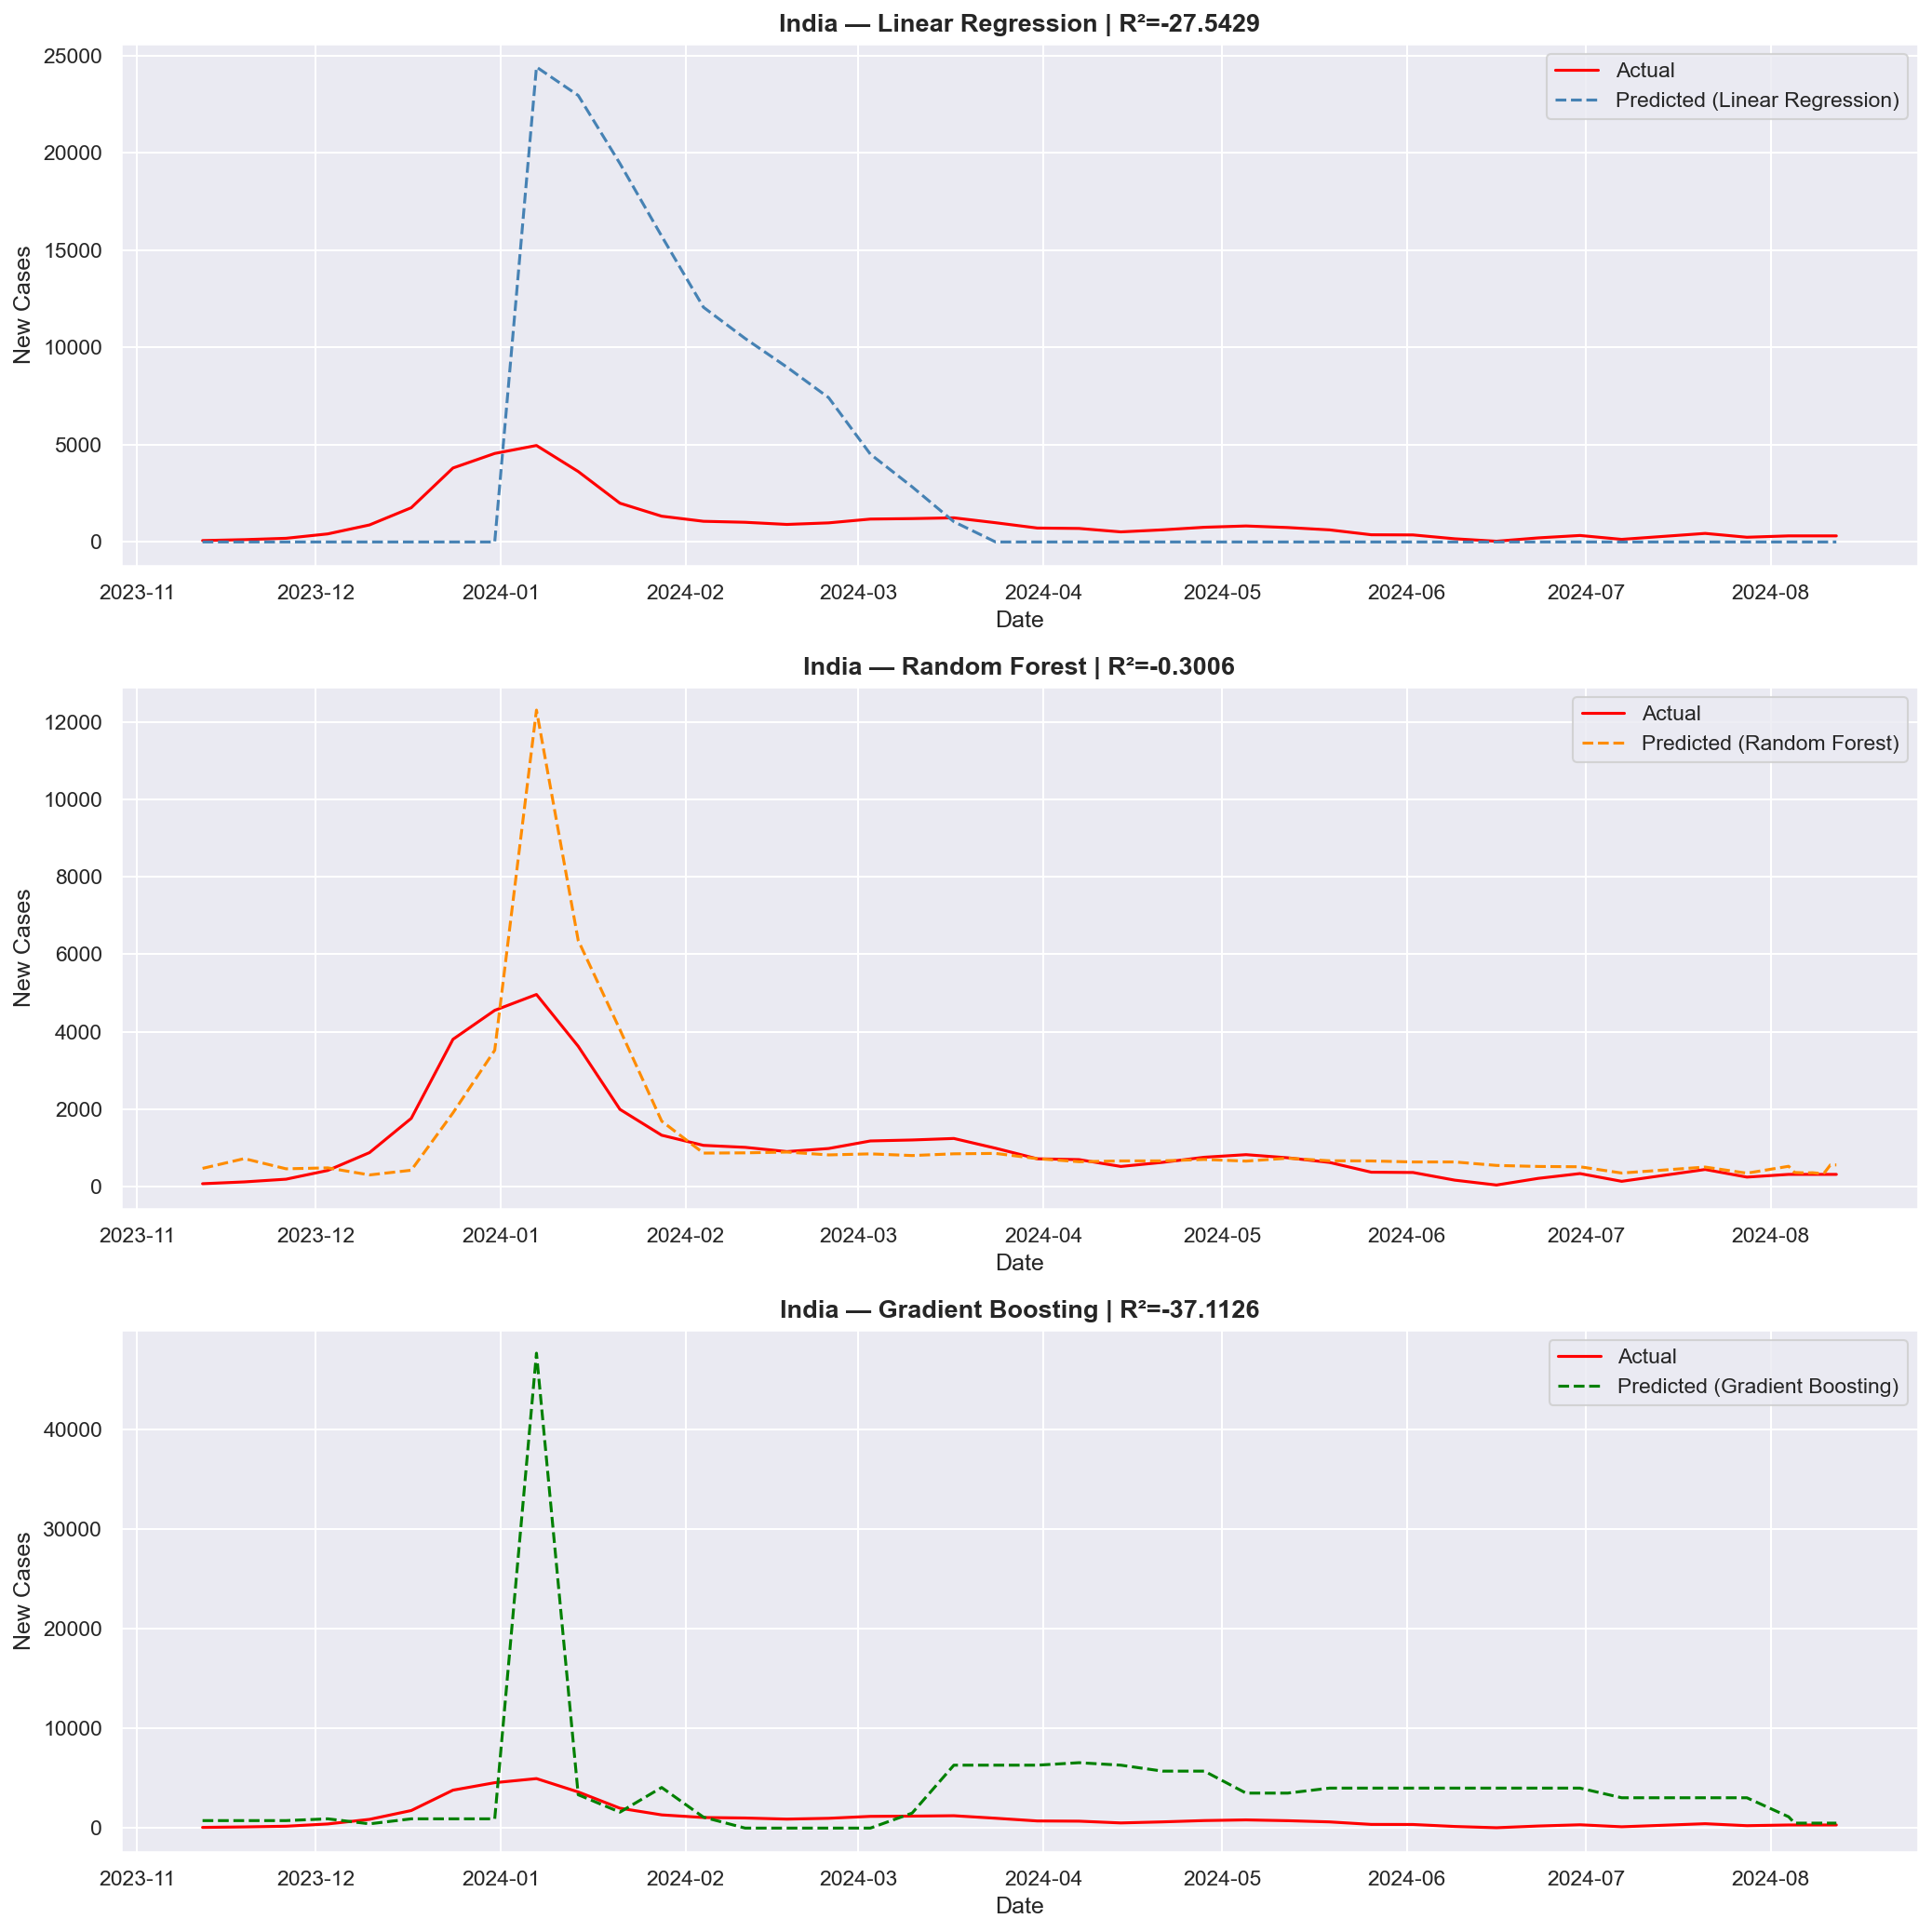

✅ Saved chart6_model_comparison.png


In [11]:
test_dates = country_df['date'].iloc[split:].reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

colors = ['steelblue', 'darkorange', 'green']

for i, (name, pred) in enumerate(predictions.items()):
    axes[i].plot(test_dates, y_test.reset_index(drop=True), 
                 label='Actual', color='red', linewidth=1.5)
    axes[i].plot(test_dates, pred, 
                 label=f'Predicted ({name})', color=colors[i], 
                 linewidth=1.5, linestyle='--')
    axes[i].set_title(f'{COUNTRY} — {name} | R²={results[name]["R2"]}', 
                      fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('New Cases')
    axes[i].legend()

plt.tight_layout()
plt.savefig('visuals/chart6_model_comparison.png')
plt.show()
print("✅ Saved chart6_model_comparison.png")

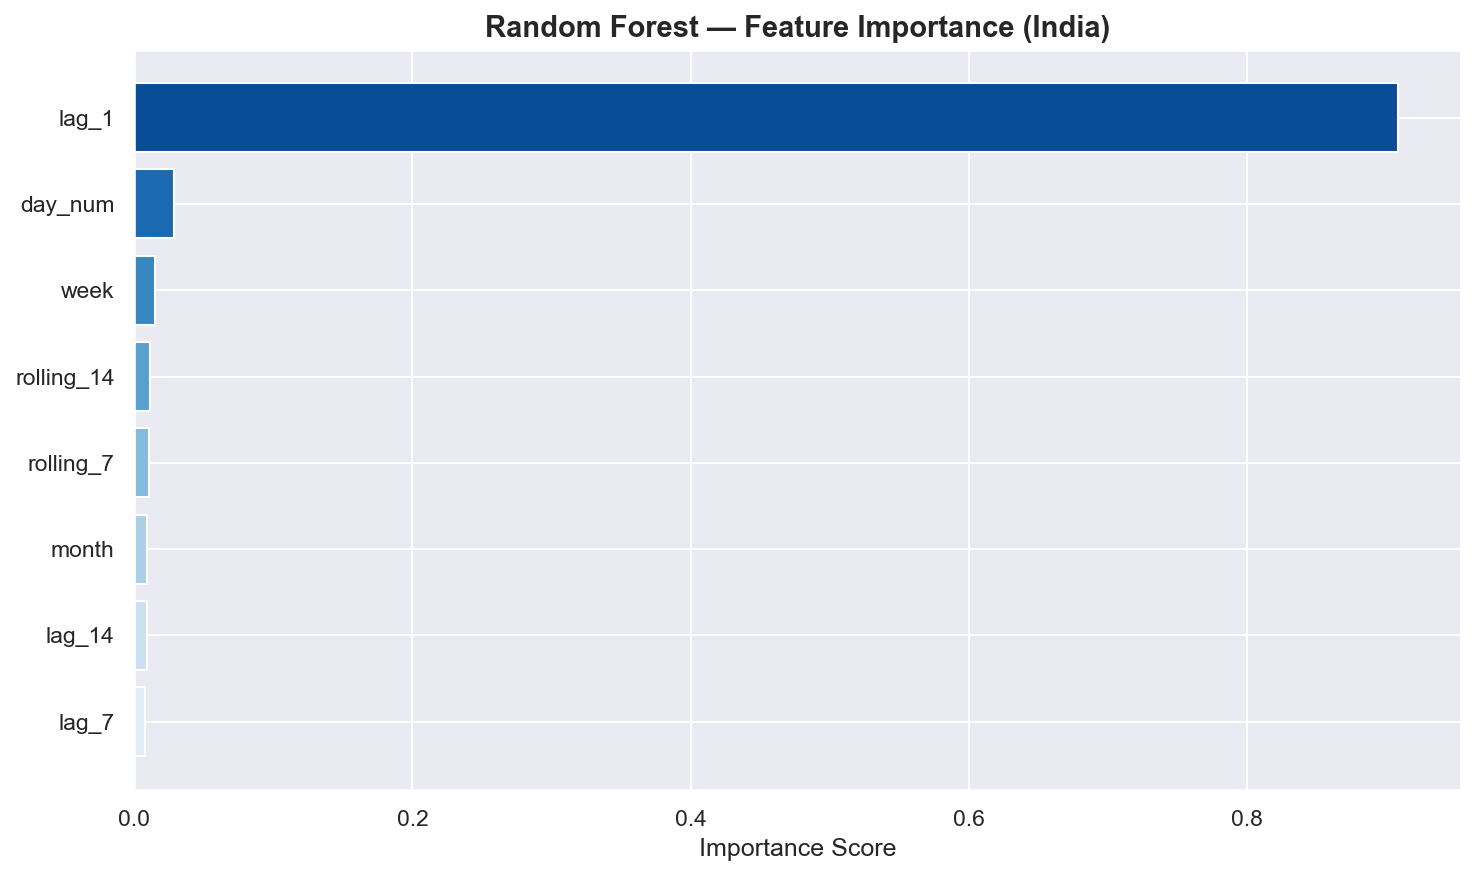

✅ Saved chart7_feature_importance.png


In [12]:
best_model = models['Random Forest']

feat_imp = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'],
               color=sns.color_palette("Blues_r", len(FEATURES)))
ax.set_title(f'Random Forest — Feature Importance ({COUNTRY})', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('visuals/chart7_feature_importance.png')
plt.show()
print("✅ Saved chart7_feature_importance.png")

In [13]:
best = models['Gradient Boosting']

# Start from last known values
last_row = country_df.iloc[-1].copy()
last_cases = list(country_df['new_cases'].values)
forecast = []
last_day = country_df['day_num'].max()
last_date = country_df['date'].max()

for i in range(1, 31):
    day_num = last_day + i
    lag_1 = last_cases[-1]
    lag_7 = last_cases[-7]
    lag_14 = last_cases[-14]
    rolling_7 = np.mean(last_cases[-7:])
    rolling_14 = np.mean(last_cases[-14:])
    future_date = last_date + pd.Timedelta(days=i)
    month = future_date.month
    week = future_date.isocalendar()[1]

    features = [[day_num, lag_1, lag_7, lag_14, rolling_7, rolling_14, month, week]]
    pred = best.predict(features)[0]
    pred = max(pred, 0)
    
    forecast.append({'date': future_date, 'forecasted_cases': round(pred)})
    last_cases.append(pred)

forecast_df = pd.DataFrame(forecast)
print(forecast_df)

         date  forecasted_cases
0  2024-08-13               499
1  2024-08-14               499
2  2024-08-15               499
3  2024-08-16               499
4  2024-08-17               499
5  2024-08-18               499
6  2024-08-19               499
7  2024-08-20               499
8  2024-08-21               499
9  2024-08-22               499
10 2024-08-23               499
11 2024-08-24               499
12 2024-08-25               499
13 2024-08-26               499
14 2024-08-27               499
15 2024-08-28               499
16 2024-08-29               499
17 2024-08-30               499
18 2024-08-31               499
19 2024-09-01               499
20 2024-09-02               499
21 2024-09-03               499
22 2024-09-04               499
23 2024-09-05               499
24 2024-09-06               499
25 2024-09-07               499
26 2024-09-08               499
27 2024-09-09               499
28 2024-09-10               499
29 2024-09-11               499


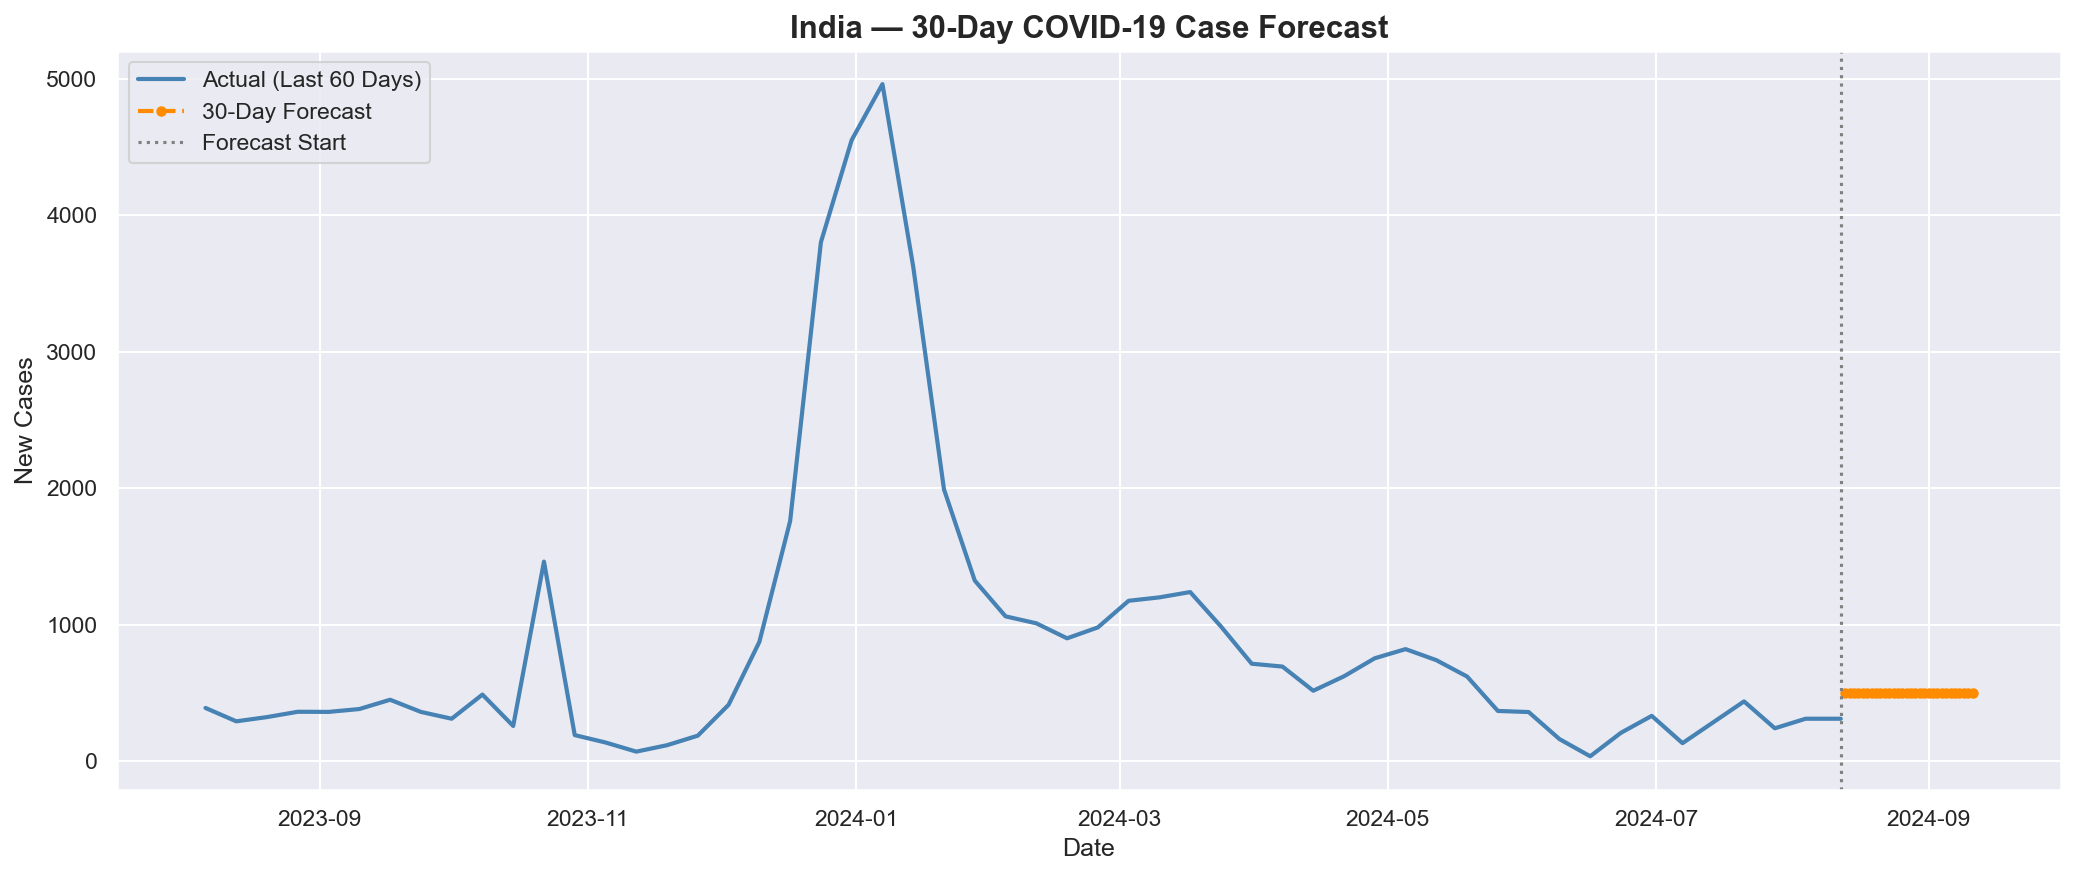

✅ Saved chart8_forecast.png


In [14]:
# Last 60 days actual + 30 days forecast
recent = country_df.tail(60)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(recent['date'], recent['new_cases'], 
        label='Actual (Last 60 Days)', color='steelblue', linewidth=2)
ax.plot(forecast_df['date'], forecast_df['forecasted_cases'], 
        label='30-Day Forecast', color='darkorange', 
        linewidth=2, linestyle='--', marker='o', markersize=4)
ax.axvline(x=country_df['date'].max(), color='gray', 
           linestyle=':', linewidth=1.5, label='Forecast Start')
ax.set_title(f'{COUNTRY} — 30-Day COVID-19 Case Forecast', 
             fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('New Cases')
ax.legend()
plt.tight_layout()
plt.savefig('visuals/chart8_forecast.png')
plt.show()
print("✅ Saved chart8_forecast.png")

In [15]:
forecast_df.to_csv('data/forecast_india.csv', index=False)

print("=" * 50)
print(f"  COVID-19 ML FORECASTING SUMMARY — {COUNTRY}")
print("=" * 50)
print(f"\n📊 Data used:     {len(country_df)} days")
print(f"🧠 Models trained: Linear Regression, Random Forest, Gradient Boosting")
print(f"\n📈 Model Performance (Test Set):")
print(results_df.to_string())
print(f"\n🔮 30-Day Forecast saved to: data/forecast_india.csv")
print(f"📁 Charts saved to visuals/")
print("\n✅ Notebook 3 Complete!")

  COVID-19 ML FORECASTING SUMMARY — India

📊 Data used:     226 days
🧠 Models trained: Linear Regression, Random Forest, Gradient Boosting

📈 Model Performance (Test Set):
                       MAE     RMSE       R2
Random Forest       529.11  1275.53  -0.3006
Linear Regression  2917.89  5975.47 -27.5429
Gradient Boosting  3050.97  6904.90 -37.1126

🔮 30-Day Forecast saved to: data/forecast_india.csv
📁 Charts saved to visuals/

✅ Notebook 3 Complete!
